In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import ast
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

from typing import Dict, List, Optional, Tuple, Union

# Большие словари для индетификации вакансий

In [124]:
key_job_words = {
    "frontend": ['frontend', 'vue', 'react', 'angular', 'javascript'],
    "backend": ['backend', 'java', 'spring', 'node', 'kotlin', 'django', 'flask'],
    "devops": ['devops', 'docker', 'kubernetes', 'ansible', 'ci/cd', 'terraform'],
    "data_scientist": ['data scientist', 'машинное обучение', 'ml engineer', 'ml-инженер'],
    "data_analyst": ['аналитик', 'data analyst', 'bi analyst', 'sql', 'analyst'],
    "data_engineer": ['data engineer', 'etl', 'pipeline', 'airflow', 'spark'],
    "qa": ['qa', 'тестировщик', 'тестирование', 'quality assurance'],
    "manager": ['менеджер', 'product manager', 'project manager'],
    "developer": ['разработчик', 'developer', 'программист', 'software engineer', 'инженер'],
    "consultant": ['консультант', 'consultant', 'support', 'сопровождение'],
    "specialist": ['специалист', 'specialist']
}

language_keywords = {
    'python': ['python'],
    'java': ['java'],
    'kotlin': ['kotlin'],
    'javascript': ['javascript', 'js', 'node.js', 'nodejs'],
    'typescript': ['typescript', 'ts'],
    'c++': ['c++', 'с++', 'cpp'],
    'c#': ['c#', 'c sharp', 'с#'],
    'go': ['golang', 'go'],
    'php': ['php'],
    'sql': ['sql'],
    'ruby': ['ruby', 'ruby on rails'],
    'swift': ['swift'],
    'scala': ['scala'],
    'bash': ['bash', 'shell'],
    '1c': ['1c', '1с', '1С'],
}

level_keywords = {
    'intern': ['intern', 'стажёр', 'стажер', 'практикант'],
    'junior': ['junior', 'джуниор', 'младший'],
    'middle': ['middle', 'мидл'],
    'senior': ['senior', 'сеньор', 'старший', 'ведущий'],
    'lead': ['lead', 'тимлид', 'руководитель', 'head'],
    'architect': ['архитектор', 'architect'],
}


# Большой предобработчик для трейна + переиспользования на тесте

In [ ]:
def preprocess_df_with_reuse(
    df: pd.DataFrame,
    key_words: Dict[str, List[str]],
    language_keywords: Dict[str, List[str]],
    level_keywords: Dict[str, List[str]],
    top_skills: Optional[List[str]] = None,
    tfidf_model: Optional[TfidfVectorizer] = None,
    tfidf_max_features: int = 100
) -> Tuple[pd.DataFrame, List[str], TfidfVectorizer]:
    """
    Предварительно обрабатывает датафрейм с вакансиями, извлекая признаки и преобразовывая данные.
    
    Параметры:
        df: Исходный датафрейм с вакансиями
        key_words: Словарь соответствия профессий и ключевых слов
        language_keywords: Словарь соответствия языков и ключевых слов
        level_keywords: Словарь соответствия уровней опыта и ключевых слов
        top_skills: Список топовых навыков (если None, будет вычислен)
        tfidf_model: Предобученная TF-IDF модель (если None, будет обучена)
        tfidf_max_features: Максимальное количество TF-IDF признаков
        
    Возвращает:
        Кортеж из:
        - Обработанный датафрейм
        - Список используемых топовых навыков
        - Обученная TF-IDF модель
    """

    def extract_first_match(text: str, keyword_dict: Dict[str, List[str]]) -> Optional[str]:
        """
        Извлекает первую подходящую категорию из текста с использованием словаря ключевых слов.
        
        Параметры:
            text: Анализируемый текст
            keyword_dict: Словарь формата {метка: [ключевые_слова]}
            
        Возвращает:
            Найденную метку или None если совпадений нет
        """
        text = str(text).lower()
        for label, keywords in keyword_dict.items():
            for k in keywords:
                pattern = rf'\b{re.escape(k)}\b'
                if re.search(pattern, text):
                    return label
        return None

    def extract_level_from_row(row: pd.Series) -> Optional[str]:
        """
        Извлекает уровень опыта из строки датафрейма, проверяя несколько колонок.
        
        Параметры:
            row: Строка датафрейма с колонками 'Employer' и 'Description'
            
        Возвращает:
            Уровень опыта или None если не найден
        """
        text1 = str(row['Employer']).lower()
        for label, keywords in level_keywords.items():
            for k in keywords:
                if re.search(rf'\b{re.escape(k)}\b', text1):
                    return label
        
        text2 = str(row['Description']).lower()
        for label, keywords in level_keywords.items():
            for k in keywords:
                if re.search(rf'\b{re.escape(k)}\b', text2):
                    return label
        return None

    def extract_language_from_row(row: pd.Series) -> Optional[str]:
        """
        Извлекает язык программирования из строки датафрейма.
        
        Параметры:
            row: Строка датафрейма с колонками 'Employer', 'Keys' и 'Description'
            
        Возвращает:
            Язык программирования или None если не найден
        """
        text1 = str(row['Employer']).lower()
        for label, keywords in language_keywords.items():
            for k in keywords:
                if re.search(rf'\b{re.escape(k)}\b', text1):
                    return label
        
        text2 = str(row['Keys']).lower()
        for label, keywords in language_keywords.items():
            for k in keywords:
                if re.search(rf'\b{re.escape(k)}\b', text2):
                    return label
        
        text3 = str(row['Description']).lower()
        for label, keywords in language_keywords.items():
            for k in keywords:
                if re.search(rf'\b{re.escape(k)}\b', text3):
                    return label
        return None

    foreign_keywords = [
        'ltd', 'inc', 'corp', 'limited', 'gmbh', 'co.', 'solutions',
        'group', 'media', 'technologies', 'technology', 'consulting',
        'recruitment', 'holding', 'team', 'studio', 'systems', 'digital',
        'international', 'global', 'ventures', 'capital', 'labs', 'soft', 'dev'
    ]

    def is_foreign_company(name: str, keywords: List[str] = foreign_keywords) -> int:
        """
        Определяет является ли компания иностранной по названию.
        
        Параметры:
            name: Название компании
            keywords: Список ключевых слов для идентификации
            
        Возвращает:
            1 если компания иностранная, 0 если нет
        """
        name = str(name).lower()
        for word in keywords:
            if word in name:
                return 1
        return 0

    def parse_keys(x: str) -> List[str]:
        """
        Парсит строку с навыками в список.
        
        Параметры:
            x: Строка с навыками (может быть в формате списка Python)
            
        Возвращает:
            Список навыков или пустой список при ошибке
        """
        if pd.isna(x) or x == '[]':
            return []
        try:
            return ast.literal_eval(x)
        except:
            return []

    # Основной код обработки...
    df['Profession'] = df['Employer'].apply(lambda x: extract_first_match(x, key_words))
    df['Language'] = df.apply(extract_language_from_row, axis=1)
    df['Level'] = df.apply(extract_level_from_row, axis=1)
    df['is_foreign'] = df['Employer'].apply(is_foreign_company)

    df['ParsedKeys'] = df['Keys'].apply(parse_keys)
    df['KeysText'] = df['ParsedKeys'].apply(lambda x: ' '.join(x).lower())
    df['NumSkills'] = df['ParsedKeys'].apply(len)

    # === One-hot по скиллам ===
    if top_skills is None:
        all_skills = [skill.lower() for skills in df['ParsedKeys'] for skill in skills]
        top_skills = [skill for skill, _ in Counter(all_skills).most_common(50)]

    for skill in top_skills:
        df[f'skill_{skill}'] = df['ParsedKeys'].apply(lambda skills: int(skill in [s.lower() for s in skills]))

    # === TF-IDF ===
    if tfidf_model is None:
        tfidf_model = TfidfVectorizer(max_features=tfidf_max_features, ngram_range=(1, 2))
        tfidf_matrix = tfidf_model.fit_transform(df['KeysText'].fillna(''))
    else:
        tfidf_matrix = tfidf_model.transform(df['KeysText'].fillna(''))

    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_keys_{t}' for t in tfidf_model.get_feature_names_out()])
    df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

    # === Encoding Experience and Schedule ===
    exp_map = {
        'Нет опыта': 0,
        'От 1 года до 3 лет': 1,
        'От 3 до 6 лет': 2,
        'Более 6 лет': 3
    }
    df['Experience_encoded'] = df['Experience'].map(exp_map)

    schedule_map = {
        'Удаленная работа': 0,
        'Полный день': 1,
        'Сменный график': 2
    }
    df['Schedule_encoded'] = df['Schedule'].map(schedule_map)

    level_encoding = {
    'intern': 0,
    'junior': 1,
    'middle': 2,
    'senior': 3,
    'lead': 4,
    'architect': 5
    }
    df['Level_encoded'] = df['Level'].map(level_encoding)

    df = df.fillna(-1)

    return df, top_skills, tfidf_model



# Обучаемся только на строках в которых есть зарплата, потом заполняем нулевые вакансии моделью

In [ ]:
def train_and_predict_catboost(
    df: pd.DataFrame,
    target_col: str = 'Salary'
) -> Tuple[float, pd.DataFrame]:
    """
    Обучает модель CatBoost на данных с известными зарплатами и делает предсказания для пропущенных значений.

    Параметры:
        df: Исходный датафрейм с данными о вакансиях
        target_col: Название целевой колонки (по умолчанию 'Salary')

    Возвращает:
        Кортеж из:
        - RMSE на обучающей выборке
        - Датафрейм с предсказанными зарплатами для строк, где зарплата отсутствовала
    """
    # Выбираем только строки, где Salary > 0 для обучения
    train_data = df[df[target_col] > 0].copy()
    
    # Определяем, какие колонки не использовать в качестве признаков.
    # Обычно это: целевая переменная и необработанные текстовые/списковые столбцы.
    # Здесь мы убираем: target, ParsedKeys, KeysText, Keys, Employer.
    features_to_drop = [target_col, 'ParsedKeys', 'KeysText', 'Keys', 'Employer', "Name", 'Experience','Schedule','Description']
    
    # Формируем обучающую матрицу признаков
    X_train = train_data.drop(columns=features_to_drop, errors='ignore')
    y_train = train_data[target_col]
    
    # Для замера качества проведём предсказание на тех же данных (можно разделить на трейн/валидацию,
    # но для baseline просто замерим на обучающем наборе)
    X_test = X_train.copy()
    y_test = y_train.copy()
    
    # Определяем категориальные признаки (если dtype=object)
    cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
    
    # Обучаем CatBoost
    model = CatBoostRegressor(verbose=1, iterations = 1500 )
    model.fit(X_train, y_train, cat_features=cat_features)
    
    # Предсказание и вычисление RMSE
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    print("Train RMSE (Salary > 0):", rmse)
    
    # Теперь отбираем строки, где Salary <= 0, для которых нужно предсказать значение
    missing_data = df[df[target_col] <= 0].copy()
    X_missing = missing_data.drop(columns=features_to_drop, errors='ignore')
    missing_preds = model.predict(X_missing)
    
    # Возвращаем RMSE на обучающем наборе и DataFrame с предсказаниями для строк с Salary <= 0.
    # Для наглядности выводим столбец 'Name' (название вакансии) и предсказанную зарплату.
    return rmse, missing_data.assign(PredictedSalary=missing_preds)

# обучаемся на полном датасете с синтетическими данными, и делаем выходной самбишн

In [ ]:
def retrain_with_filled_and_predict(
    train_df: pd.DataFrame,
    missing_preds_df: pd.DataFrame,
    test_df: pd.DataFrame
) -> Tuple[pd.DataFrame, float, List[float]]:
    """
    Переобучает модель на данных с заполненными пропущенными зарплатами и делает предсказания.
    
    Параметры:
        train_df: Обучающий датафрейм с исходными данными (включая пропущенные зарплаты)
        missing_preds_df: Дадафрейм с предсказанными зарплатами для пропущенных значений
        test_df: Тестовый датафрейм для финального предсказания
        
    Возвращает:
        Кортеж из:
        - Предсказанные значения для тестовой выборки
        - RMSE на валидационной выборке
        - Список важностей признаков
    """
    # 1. Вставим предсказанную зарплату обратно в строки, где её не было
    missing_part = train_df[train_df['Salary'] <= 0].copy()
    missing_part['Salary'] = missing_preds_df['PredictedSalary'].values

    # 2. Оставшиеся строки с правильными зарплатами
    clean_part = train_df[train_df['Salary'] > 0].copy()

    # 3. Объединяем
    full_train = pd.concat([clean_part, missing_part], ignore_index=True)
    full_train = full_train.sample(frac=1, random_state=42).reset_index(drop=True)

    # 4. Готовим X, y
    features_to_drop = ['Salary', 'ParsedKeys', 'KeysText', 'Keys', 'Employer', "Name", 'Experience','Schedule','Description']
    X = full_train.drop(columns=features_to_drop, errors='ignore')
    y = full_train['Salary']

    # 5. Сплит на обучение/валидацию
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # 6. Обучаем CatBoost
    cat_features = X.select_dtypes(include='object').columns.tolist()
    model = CatBoostRegressor(verbose=1, iterations= 1000)
    model.fit(X_train, y_train, cat_features=cat_features)

    # 7. Предсказание на валидации
    val_preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, val_preds, squared=False)
    print(f"RMSE на валидации: {rmse:.2f}")

    # 8. Предсказание на тестовой выборке
    test_features = test_df.drop(columns=features_to_drop, errors='ignore')
    test_preds = model.predict(test_features)

    return test_preds


In [ ]:
train_df = pd.read_csv(r"C:\Users\nodos\Downloads\train (2).csv")
test_df = pd.read_csv(r"C:\Users\nodos\Downloads\test (2).csv")

train_df, top_skills, tfidf_model = preprocess_df_with_reuse(train_df)
test_df, _, _ = preprocess_df_with_reuse(
    test_df,
    top_skills=top_skills,
    tfidf_model=tfidf_model
)


In [130]:
rmse, missing_preds_df = train_and_predict_catboost(train_df)
print(rmse)

Learning rate set to 0.028352
0:	learn: 112335.5612067	total: 32.6ms	remaining: 48.8s
1:	learn: 110990.4609467	total: 62.4ms	remaining: 46.7s
2:	learn: 109832.8787435	total: 93.4ms	remaining: 46.6s
3:	learn: 108605.2046738	total: 116ms	remaining: 43.5s
4:	learn: 107404.6430197	total: 140ms	remaining: 42s
5:	learn: 106309.2323595	total: 172ms	remaining: 42.9s
6:	learn: 105199.3619774	total: 220ms	remaining: 47s
7:	learn: 104143.6521068	total: 252ms	remaining: 46.9s
8:	learn: 103298.2581313	total: 297ms	remaining: 49.1s
9:	learn: 102360.8072094	total: 326ms	remaining: 48.5s
10:	learn: 101457.4620135	total: 357ms	remaining: 48.3s
11:	learn: 100720.1596880	total: 389ms	remaining: 48.2s
12:	learn: 99846.1777938	total: 419ms	remaining: 47.9s
13:	learn: 99036.0309086	total: 452ms	remaining: 48s
14:	learn: 98325.3865647	total: 510ms	remaining: 50.5s
15:	learn: 97633.2071550	total: 545ms	remaining: 50.6s
16:	learn: 96913.1652709	total: 576ms	remaining: 50.3s
17:	learn: 96243.1078023	total: 606m

C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [132]:
test_preds = retrain_with_filled_and_predict(train_df, missing_preds_df, test_df)

submission = pd.DataFrame({'Salary': test_preds})
submission.to_csv('submission_salary_catboost2.csv', index=False)

Learning rate set to 0.039648
0:	learn: 107654.3067199	total: 26.9ms	remaining: 26.9s
1:	learn: 105867.2673898	total: 58.7ms	remaining: 29.3s
2:	learn: 104028.4850261	total: 89.1ms	remaining: 29.6s
3:	learn: 102374.4826114	total: 120ms	remaining: 29.9s
4:	learn: 100918.6585831	total: 132ms	remaining: 26.2s
5:	learn: 99620.0399554	total: 162ms	remaining: 26.9s
6:	learn: 98181.8707499	total: 198ms	remaining: 28.1s
7:	learn: 96778.1235580	total: 231ms	remaining: 28.6s
8:	learn: 95372.4534020	total: 262ms	remaining: 28.9s
9:	learn: 94108.8908553	total: 293ms	remaining: 29s
10:	learn: 92885.4940334	total: 315ms	remaining: 28.3s
11:	learn: 91670.0376257	total: 355ms	remaining: 29.3s
12:	learn: 90575.0263744	total: 382ms	remaining: 29s
13:	learn: 89410.6623997	total: 417ms	remaining: 29.4s
14:	learn: 88404.7087514	total: 449ms	remaining: 29.5s
15:	learn: 87425.3395368	total: 480ms	remaining: 29.5s
16:	learn: 86518.4480039	total: 511ms	remaining: 29.6s
17:	learn: 85710.5563293	total: 544ms	rem

C:\Users\nodos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Тут researcher alley

In [ ]:
#Считаю значения None в столбцах Profession, Language и Level
none_counts = {
    'Profession': train_df['Profession'].isna().sum(),
    'Language': train_df['Language'].isna().sum(),
    'Level': train_df['Level'].isna().sum()
}

# Посмотрим на процент
total_rows = len(train_df)
none_percentages = {k: (v / total_rows) * 100 for k, v in none_counts.items()}

# Даиафрейм для визуализации
none_df = pd.DataFrame({
    'Count': none_counts,
    'Percentage': none_percentages
})

print("Number of None values and their percentages:")
display(none_df)

print(f"\nTotal number of rows in train_df: {total_rows}")

Number of None values and their percentages:


,Count,Percentage
Profession,44,4.309500
Language,139,13.614104
Level,548,53.672870



Total number of rows in train_df: 1021


In [72]:
train_df['Schedule'].unique()

array(['Удаленная работа', 'Полный день', 'Сменный график'], dtype=object)

In [57]:
text_cols = ['Name', 'Employer', 'Description', 'Keys']
for col in text_cols:
    train_df[col] = train_df[col].astype(str).str.lower()

In [ ]:
# Исключить эти слова
exclude_words = ['разработчик', 'программист', 'developer', 'engineer',"инженер", 
                 'аналитик', 'analyst', 
                 'scientist', "QA", 'data',
                 'менеджер', 'manager', 'консультант', 
                 'lead', 'руководитель',
                 'специалист', 'specialist'
                 '1c', '1С']

# шаблон регулярного выражения из исключенных слов
pattern = '|'.join(exclude_words)

# фильтр
filtered_employers = train_df[
    (train_df['Salary'] >= 0) & 
    (~train_df['Employer'].str.contains(pattern, case=False, na=False))
]['Employer']

pd.set_option('display.max_rows', None)
print(len(filtered_employers))
print(filtered_employers)
pd.reset_option('display.max_rows')

10
87     Техник цифровой обработки сигналов
216                  Intern Game Producer
218                          DevOps\MLOps
262                  Accountant assistant
428                      Наставник Python
487                  Frontend-верстальщик
532           Junior Fullstack specialist
611                            Маркетолог
630                 Аудитор отдела продаж
692       UX/UI проектировщик интерфейсов
Name: Employer, dtype: object


In [ ]:
text = ' '.join(filtered_employers).lower()

# Разделение текста на слова и подсчет частоты
words = text.split()
word_counts = Counter(words)

top_10_words = word_counts.most_common(20)
top_10_words

[('специалист', 10),
 ('по', 7),
 ('руководитель', 7),
 ('1с', 6),
 ('manager', 6),
 ('отдела', 5),
 ('проектов', 5),
 ('revenue', 4),
 ('/', 4),
 ('управляющая', 4),
 ('компания', 4),
 ('rodina', 4),
 ('hotels', 4),
 ('qa', 4),
 ('manual', 4),
 ('главный', 4),
 ('(backend/frontend/mobile)', 3),
 ('data', 3),
 ('scientist', 3),
 ('стажер', 3)]

In [8]:
filtered_df = train_df[(train_df['Salary'] > 0) & 
                       (train_df['Employer'].str.contains('frontend|Frontend', case=False, na=False))]
display(filtered_df)

,Ids,Employer,Name,Salary,Experience,Schedule,Keys,Description
0,119042360,Frontend-разработчик (Vue.js),Tashir Estate,150000.0,От 1 года до 3 лет,Удаленная работа,[],Tashir Estate является одним из крупнейших дев...
6,118085242,Senior frontend-разработчик (react),Tool-Kit,250000.0,От 1 года до 3 лет,Удаленная работа,"['JavaScript', 'HTML', 'Node.js', 'CSS', 'Reac...","Привет, соискатель! Ты наткнулся на вакансию, ..."
12,119112087,Frontend разработчик (JS),РТУ МИРЭА,100000.0,От 1 года до 3 лет,Полный день,"['PHP', 'Yii 2', 'MySQL', 'JavaScript', 'Ajax'...",Чем предстоит заниматься: Разработка новых ин...
27,118743968,Junior frontend-разработчик в команду техничес...,Any,60000.0,От 1 года до 3 лет,Удаленная работа,"['HTML', 'JavaScript', 'REST API', 'Верстка са...",Any (ранее DIGINETICA) — лидер в области персо...
65,118706290,Middle Frontend Developer (iGaming),Койпиш Артем,158215.0,От 3 до 6 лет,Удаленная работа,[],О вас:— 4+ года опыта в frontend-разработке (H...
...,...,...,...,...,...,...,...,...
979,118228515,Frontend-разработчик,RecruitTech,250000.0,От 1 года до 3 лет,Полный день,"['JavaScript', 'HTML5', 'CSS3', 'TypeScript', ...",Привет! Мы аккредитованная IT-компания. За 7 л...
989,116708267,Frontend-developer (React & Vue3) / Фронтэнд-р...,Брендинговое агентство BrandExpert Остров Свободы,180000.0,От 3 до 6 лет,Удаленная работа,"['CSS3', 'jQuery', 'CSS', 'JavaScript', 'Stylu...",Frontend-разработчик / Фронтэнд-developer (Fre...
992,119171371,Разработчик Frontend Vue.js (Senior+),IT-OTS,300000.0,Более 6 лет,Удаленная работа,[],Проект Мосбиржи.Основные задачи:• Работа в ком...
1011,118466923,QA manual (backend/frontend/mobile),ФАЙВДЖЕН,120000.0,От 1 года до 3 лет,Полный день,[],Мы занимаемся разработкой сложных и интересных...


In [ ]:
# Трейн-валидация сплит
train_part, val_part = train_test_split(train_df, test_size=0.2, random_state=42)

X_train_text = combine_text_fields(train_part)
y_train = train_part["Salary"]

X_val_text = combine_text_fields(val_part)
y_val = val_part["Salary"]

X_test_text = combine_text_fields(test_X)

In [ ]:
#  Модель
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
model = Ridge(alpha=1.0)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_val_vec = vectorizer.transform(X_val_text)
X_test_vec = vectorizer.transform(X_test_text)

model.fit(X_train_vec, y_train)
val_preds = model.predict(X_val_vec)
val_preds = np.clip(val_preds, 0, None)

In [ ]:
#  Оценка
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"RMSE на валидации: {val_rmse:,.2f} руб")


RMSE на валидации: 94,228.22 руб


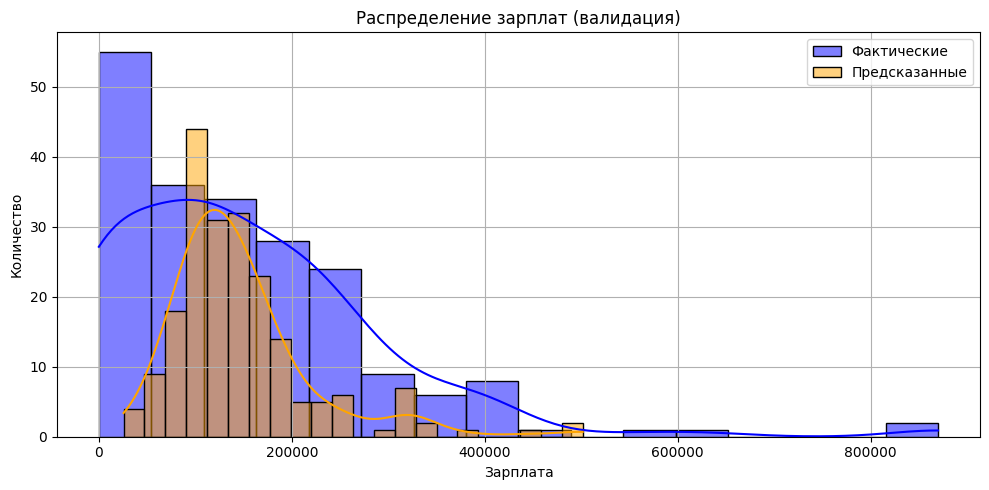

In [ ]:
# Распределение реальных и предсказанных зарплат
plt.figure(figsize=(10, 5))
sns.histplot(y_val, label='Фактические', kde=True, color='blue')
sns.histplot(val_preds, label='Предсказанные', kde=True, color='orange')
plt.title("Распределение зарплат (валидация)")
plt.xlabel("Зарплата")
plt.ylabel("Количество")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Промежуточный вывод**  

+ В зоне высоких зарплат (600,000+ руб.) предсказанная кривая может значительно отклоняться от фактической.  

+ В зоне низких зарплат (близко к 0) также возможны занижения/завышения.  

+ Высокое значение RMSE (94,228.22 руб.) подтверждает, что модель ошибается сильнее всего именно в крайних диапазонах, где расхождения на графике наиболее заметны.  

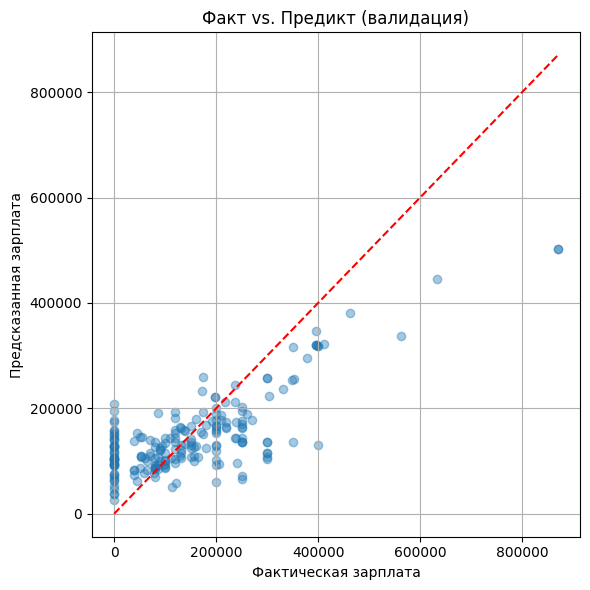

In [ ]:
# Scatter plot: предсказания vs. реальные
plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_preds, alpha=0.4)
plt.plot([0, max(y_val)], [0, max(y_val)], color='red', linestyle='--')
plt.xlabel("Фактическая зарплата")
plt.ylabel("Предсказанная зарплата")
plt.title("Факт vs. Предикт (валидация)")
plt.grid(True)
plt.tight_layout()
plt.show()


**Промежуточный вывод**  

График подтверждает, что модель требует доработок для крайних значений. Нужно попробовать через логарифмирование и фичи для "дорогих" вакансий

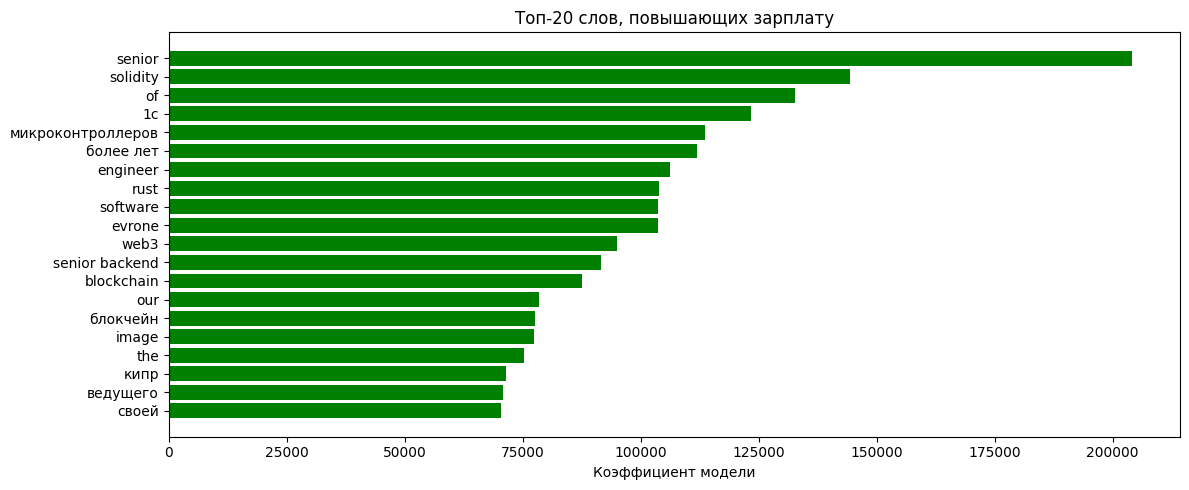

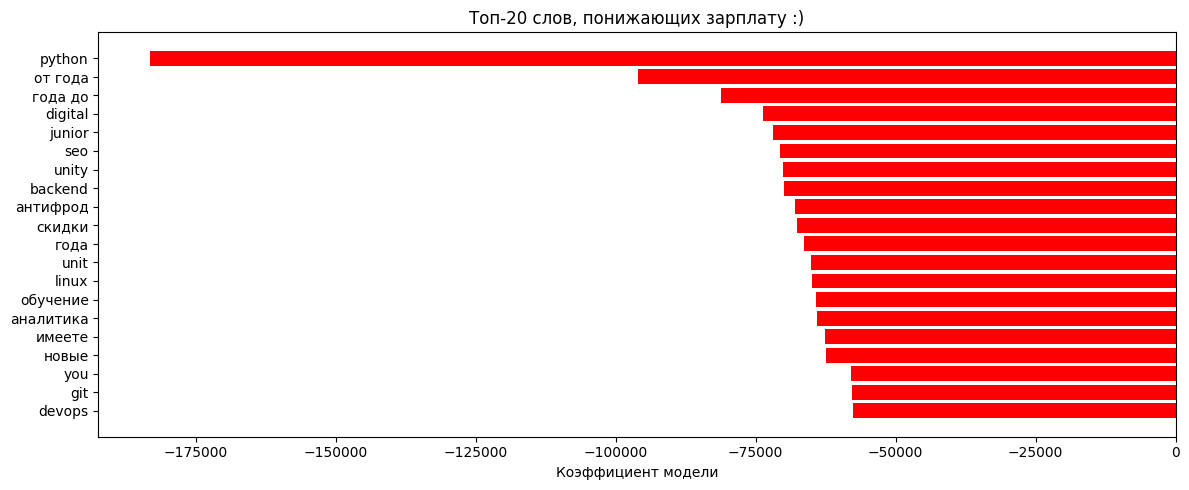

In [ ]:
# Топ-20 самых важных слов
coefs = model.coef_
feature_names = vectorizer.get_feature_names_out()
top_n = 20

top_positive = np.argsort(coefs)[-top_n:][::-1]
top_negative = np.argsort(coefs)[:top_n]

plt.figure(figsize=(12, 5))
plt.barh([feature_names[i] for i in top_positive][::-1],
         [coefs[i] for i in top_positive][::-1], color='green')
plt.title("Топ-20 слов, повышающих зарплату")
plt.xlabel("Коэффициент модели")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.barh([feature_names[i] for i in top_negative][::-1],
         [coefs[i] for i in top_negative][::-1], color='red')
plt.title("Топ-20 слов, понижающих зарплату :)")
plt.xlabel("Коэффициент модели")
plt.tight_layout()
plt.show()